# Cross-strategy diagnostics (IDCD, CAT, DAT)

This notebook complements the strategy-specific tutorials. It fits **IDCD-, CAT-, and DAT-CLARA** on the same aligned sample and reports **pairwise partition agreement** (ARI and Jaccard), as in the paper's empirical and simulation diagnostic workflow.

Set `TUTORIAL_SUBSET_N = 2000` below for a quick run. For a single strategy with full visualization, use `idcd_md_clara_tutorial.ipynb`, `cat_md_clara_tutorial.ipynb`, or `dat_md_clara_tutorial.ipynb`.

## Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sequenzo import *
from sequenzo import SequenceData
from sequenzo.multidomain import (
    get_association_between_domains,
    plot_multidomain_sequence_index_by_cluster,
)
from sequenzo.multidomain.clara import (
    md_clara,
    plot_md_clara_quality,
    plot_dat_domain_contributions,
    leave_one_domain_out_sensitivity,
    plot_leave_one_domain_out_sensitivity,
    summarize_combined_state_space,
    compare_md_clara_strategies,
    plot_cross_strategy_agreement
)

DOMAIN_NAMES = ["occupation", "seniority"]

CLARA_R = 25
CLARA_R_DIAG = 15


def clara_sample_size(n_cases: int, max_k: int = 10) -> int:
    return min(1000, max(40 + 2 * max_k, int(0.4 * n_cases)))


TUTORIAL_SUBSET_N = None
RANDOM_STATE = 42

DATA_DIR = Path("data") # the root path is your jupyter root, not project root
OUTPUT_DIR = Path("output")


## Load data

In [2]:
OCCUPATION_CSV = DATA_DIR / "detailed_sequence_10_work_years_df_clean_year_names_column.csv"
SENIORITY_CSV = DATA_DIR / "detailed_senority_levels_for_10_years_clean_year_names_column.csv"

occupation_df = pd.read_csv(OCCUPATION_CSV)
seniority_df = pd.read_csv(SENIORITY_CSV)

common_ids = np.intersect1d(occupation_df["worker_id"], seniority_df["worker_id"])
occupation_df = (
    occupation_df[occupation_df["worker_id"].isin(common_ids)]
    .sort_values("worker_id")
    .reset_index(drop=True)
)
seniority_df = (
    seniority_df[seniority_df["worker_id"].isin(common_ids)]
    .sort_values("worker_id")
    .reset_index(drop=True)
)
assert (occupation_df["worker_id"].values == seniority_df["worker_id"].values).all()

if TUTORIAL_SUBSET_N is not None:
    occupation_df = occupation_df.head(TUTORIAL_SUBSET_N).copy()
    seniority_df = seniority_df.head(TUTORIAL_SUBSET_N).copy()

TIME_COLS = [str(i) for i in range(1, 11)]
# Same state alphabets as the strategy-specific tutorials
OCCUPATION_STATES = [
    "Data",
    "Data science",
    "Software",
    "Hardware",
    "Systems & infrastructure",
    "Research",
    "Support & test",
]
SENIORITY_STATES = [
    "Assistant/Junior",
    "Regular",
    "Senior",
    "Leader",
    "Chief/founder",
]

occupation_seq = SequenceData(
    occupation_df,
    time=TIME_COLS,
    states=OCCUPATION_STATES,
    id_col="worker_id",
)
seniority_seq = SequenceData(
    seniority_df,
    time=TIME_COLS,
    states=SENIORITY_STATES,
    id_col="worker_id",
)
domains = [occupation_seq, seniority_seq]
print(f"Individuals: {len(occupation_df):,}")


[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Data', 'Data science', 'Software', 'Hardware', 'Systems & infrastructure', 'Research', 'Support & test']
[>] Labels: ['Data', 'Data science', 'Software', 'Hardware', 'Systems & infrastructure', 'Research', 'Support & test']
[>] Void: '%' (not in states (inactive); not observed in data) — out-of-window padding; SAMM/seqsamm drops subsequences containing void
[>] Weights: Not provided
[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 32628
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Assistant/Junior', 'Re

## Fit three strategies at fixed k

In [10]:
K_COMPARE = 5  # fixed k for cross-strategy comparison

idcd_params = {"method": "OM", "sm": "CONSTANT", "indel": 1, "norm": "none", "ch_sep": "+"}
cat_params = {
    "method": "OM",
    "sm": ["CONSTANT", "CONSTANT"],
    "indel": 1,
    "norm": "none",
}
dat_params = {
    "method_params": [
        {"method": "OM", "sm": "CONSTANT", "indel": 1, "norm": "none"},
        {"method": "OM", "sm": "CONSTANT", "indel": 1, "norm": "none"},
    ],
    "link": "sum",
}

sample_size = clara_sample_size(len(occupation_df), max_k=K_COMPARE)
print(f"b = {sample_size}, R = {CLARA_R}, k = {K_COMPARE}")


b = 1000, R = 25, k = 5


In [11]:
results = {}
for strategy, params in [
    ("idcd", idcd_params),
    ("cat", cat_params),
    ("dat", dat_params),
]:
    print(f"\n=== {strategy.upper()}-CLARA ===")
    results[strategy] = md_clara(
        domains,
        strategy=strategy,
        distance_params=params,
        R=CLARA_R,
        sample_size=sample_size,
        kvals=[K_COMPARE],
        criteria=("distance",),
        stability=False,
        dat_domain_contribution=(strategy == "dat"),
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=True,
    )

agreement = compare_md_clara_strategies(results, k=K_COMPARE)
agreement



=== IDCD-CLARA ===
[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 7055
[>] Number of time points: 10
[>] Min/Max sequence length: 10 / 10
[>] States: ['Software+Regular', 'Software+Senior', 'Systems & infrastructure+Regular', 'Support & test+Regular', 'Software+Leader', 'Support & test+Senior', 'Support & test+Leader', 'Data+Regular', 'Systems & infrastructure+Senior', 'Hardware+Regular', 'Software+Assistant/Junior', 'Data science+Regular', 'Hardware+Senior', 'Hardware+Leader', 'Data+Senior', 'Data science+Senior', 'Systems & infrastructure+Leader', 'Research+Regular', 'Research+Assistant/Junior', 'Data science+Leader', 'Data+Leader', 'Hardware+Assistant/Junior', 'Systems & infrastructure+Assistant/Junior', 'Support & test+Assistant/Junior', 'Software+Chief/founder', 'Data science+Assistant/Junior', 'Research+Senior', 'Data+A

,strategy_left,strategy_right,k,ari,jaccard
0,cat,dat,5,0.612735,0.557034
1,cat,idcd,5,0.576004,0.520358
2,dat,idcd,5,0.560286,0.507713


## Compare partitions

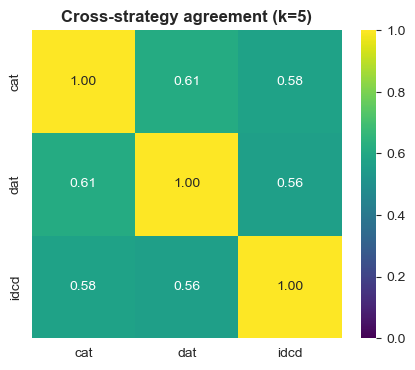

Saved to output


In [12]:
plot_cross_strategy_agreement(
    agreement,
    metric="ari",
    title=f"Cross-strategy agreement (k={K_COMPARE})",
    save_as=str(OUTPUT_DIR / f"cross_strategy_agreement_k{K_COMPARE}.png"),
)
plt.show()

agreement.to_csv(OUTPUT_DIR / f"cross_strategy_agreement_k{K_COMPARE}.csv", index=False)
print("Saved to", OUTPUT_DIR)
